[Home](../../README.md)

### Data Preprocessing

This Jupyter Notebook documents different processes I have applied to my data to better understand it before data wrangling This is the Data Preprocessing step of the MLOps process.

#### Load the required dependencies

Load the two required dependencies:

- [Numpy](https://numpy.org/doc/stable/) is a library that enables numerical computing with Python
- [Pandas](https://pandas.pydata.org/) is library for data analysis and manipulation.
- [Matplotlib](https://matplotlib.org) a comprehensive library for creating static, animated, and interactive visualizations in Python. A customised stylesheet for the visualisations is also applied.

In [1]:
# Import frameworks
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('../../style_Matplotlib_charts.mplstyle')

####  Store the data as a local variable

The data frame is a Pandas object that structures your tabular data into an appropriate format. It loads the complete data in memory so it is now ready for preprocessing.

In [2]:
data_frame = pd.read_csv("spotify_songs.csv")

#### Data Snapshot

It is important to get a high-level look at your dataset to understand what you are working with. Printing the complete data might be impossible for large-scale datasets where the rows can be in thousands or even millions.

You can use the `head()` and `tail()` method call to inspect the first and last 5 rows of your dataset.

In [3]:
# Target = A measure of disease progression in one year
data_frame.head()

,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052


####  Data Summary
 
The `info()` method call prints a summary of each column, giving you more information about the specific data types, total number of rows, null values and memory usage.

In [4]:
data_frame.info()

<class 'pandas.DataFrame'>
RangeIndex: 32833 entries, 0 to 32832
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   track_id                  32833 non-null  str    
 1   track_name                32828 non-null  str    
 2   track_artist              32828 non-null  str    
 3   track_popularity          32833 non-null  int64  
 4   track_album_id            32833 non-null  str    
 5   track_album_name          32828 non-null  str    
 6   track_album_release_date  32833 non-null  str    
 7   playlist_name             32833 non-null  str    
 8   playlist_id               32833 non-null  str    
 9   playlist_genre            32833 non-null  str    
 10  playlist_subgenre         32833 non-null  str    
 11  danceability              32833 non-null  float64
 12  energy                    32833 non-null  float64
 13  key                       32833 non-null  int64  
 14  loudness         

#### Statistics For Numerical Columns
 
The `describe()` method call provides basic statistical knowledge like the mean and spread of the data.

In [5]:
data_frame.describe()

,track_popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
count,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000
mean,42.477081,0.654850,0.698619,5.374471,-6.719499,0.565711,0.107068,0.175334,0.084747,0.190176,0.510561,120.881132,225799.811622
std,24.984074,0.145085,0.180910,3.611657,2.988436,0.495671,0.101314,0.219633,0.224230,0.154317,0.233146,26.903624,59834.006182
min,0.000000,0.000000,0.000175,0.000000,-46.448000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4000.000000
25%,24.000000,0.563000,0.581000,2.000000,-8.171000,0.000000,0.041000,0.015100,0.000000,0.092700,0.331000,99.960000,187819.000000
50%,45.000000,0.672000,0.721000,6.000000,-6.166000,1.000000,0.062500,0.080400,0.000016,0.127000,0.512000,121.984000,216000.000000
75%,62.000000,0.761000,0.840000,9.000000,-4.645000,1.000000,0.132000,0.255000,0.004830,0.248000,0.693000,133.918000,253585.000000
max,100.000000,0.983000,1.000000,11.000000,1.275000,1.000000,0.918000,0.994000,0.994000,0.996000,0.991000,239.440000,517810.000000


#### The data columns are:

| Column | Data | Datatype | Range | Units | Bias |
| ------ | ----- | ----- | ----- | ----- | ----- |
| track_popularity | Measure of popularity | float | 0 to 100 | Score | Recency bias |
| track_album_release_date | Release date of album (target) | datetime | Before February 2020 | N/A | Potentially skewed data |
| playlist_genre | Genre of playlist | string | N/A | N/A | Limited genres |
| playlist_subgenre | Subgenre of playlist | string | N/A | N/A | ? (subgenre is unusual) |
| danceability | Danceability of song^ | float | 0 to 1 | Arbitrary (0=low, 1=high)| ML bias; highly subjective |
| energy | Energy of song^ | float | 0 to 1 | Arbitrary (0=low, 1=high) | ML bias |
| key | Key of song^ | int | 0 to 11 | Pitch class notation (0=C, 1=C#, etc.) | -1 (no key detected) is possible ( according to readme of dataset) but it is not present in this dataset, suggesting all songs had a detectable key or the dataset was pre-filtered |
| loudness | Overall loudness of song | float | -60 to 0* | dB (decibels) | Averaged across track |
| mode | Modality of song (major = 1, minor = 0)^ | bool | 0 or 1 | N/A | only  major or minor |
| speechiness | Presence of spoken words^ | float | 0 to 1 | Arbitrary (0=music, 1=speech) | ML bias and English language bias |
| acousticness | Confidence track is acoustic^ | float | 0 to 1 | Arbitrary (0=not acoustic, 1=acoustic) | ML bias |
| instrumentalness | Probablility of song being fully instrumental^ | float | 0 to 1 | Arbitrary (0=vocals present, 1=instrumental) | ML bias |
| liveness | Probability of live performance^ | float | 0 to 1 | Arbitrary (0=not live, 1=live) | ML bias |
| valence | Musical positiveness^ | float | 0 to 1 | Arbitrary (0=negative, 1=positive) | ML bias; highly subjective |
| tempo | Estimated tempo^ | float | 30 to 250** | BPM (beats per minute) | ML bias; time signatures |
| duration_ms | Duration of song | float | 29500 to 517800** | Milliseconds (ms) | None |


*typical range where there is no range limit
**calculated range (aprox.)

^measured by ml so could be incorrect

#### Convert Datatypes

This is a cell from my data wrangling that has been duplicated here to allow me to view a cleaner version of the graphs

In [ ]:
# convert date to a year only for consistency
data_frame["track_album_release_date"] = pd.to_datetime(
    data_frame["track_album_release_date"], format="mixed"
).dt.year

data_frame["track_album_release_date"] = (
    data_frame["track_album_release_date"]
    .fillna(data_frame["track_album_release_date"].mean())
    .astype(int)
)

print(data_frame["track_album_release_date"].unique()) # show all unique years
print(data_frame["track_album_release_date"].info()) # ensure datatype and count are correct

[2019 2018 2017 2016 2014 2012 2015 2013 2011 2010 2008 2020 2007 1998
 1996 1999 2009 1993 1995 1991 2000 1994 1992 1997 2001 2006 2002 2003
 2005 1990 2004 1988 1984 1982 1973 1979 1977 1981 1974 1970 1976 1987
 1978 1969 1986 1980 1983 1985 1989 1975 1968 1971 1972 1967 1966 1965
 1964 1963 1962 1957 1958 1961 1960]
<class 'pandas.Series'>
RangeIndex: 32833 entries, 0 to 32832
Series name: track_album_release_date
Non-Null Count  Dtype
--------------  -----
32833 non-null  int64
dtypes: int64(1)
memory usage: 256.6 KB
None


#### Graphically present the data

At this early stage you are just wanting to evaluate the data, the below simple plots lets you look the data in different ways to inform your model design and data wrangling approaches.

<Axes: >

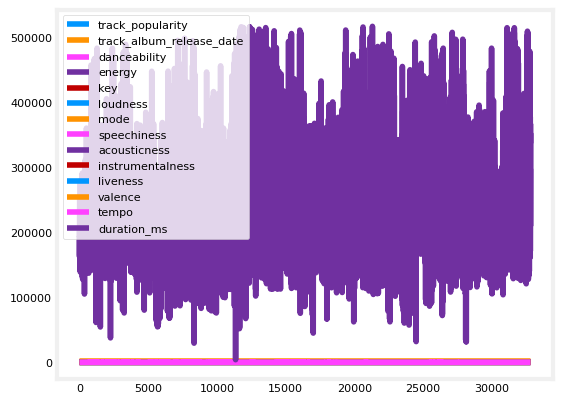

In [ ]:
# line graph of all features
target = "track_album_release_date"
data_frame.plot()

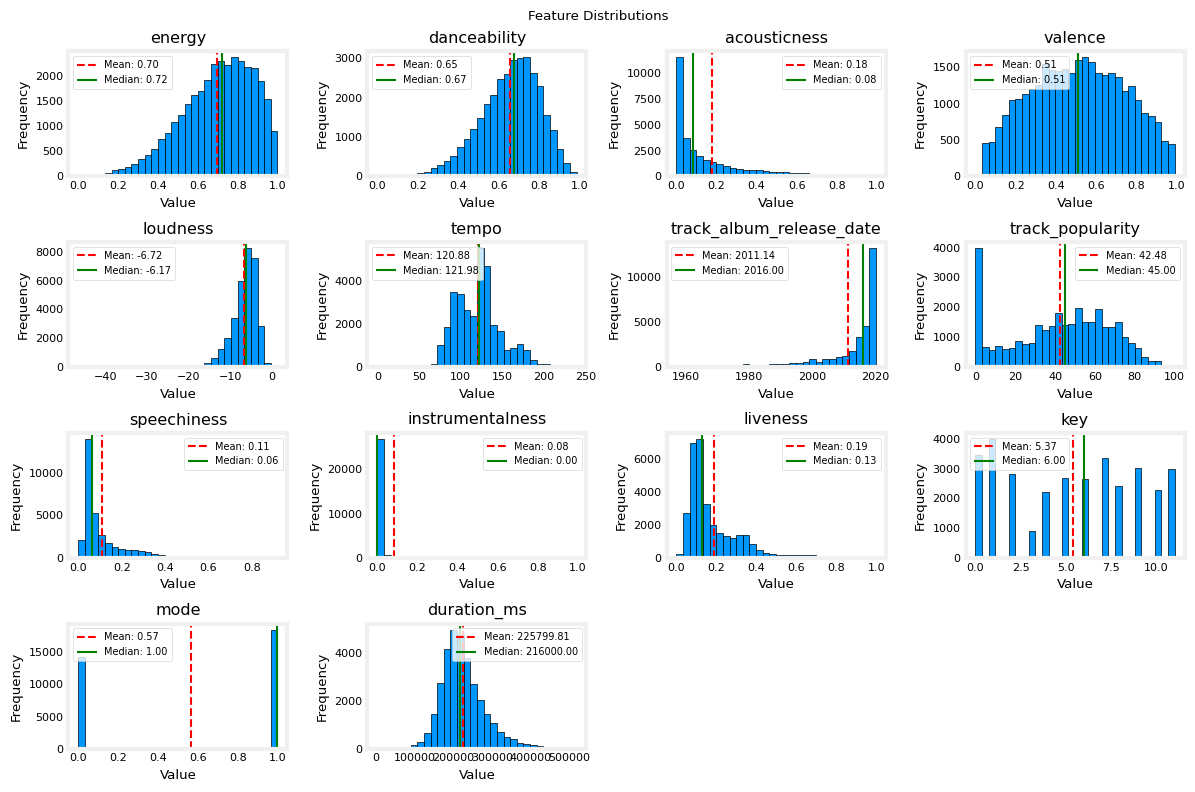

In [ ]:
#data_frame = data_frame[data_frame["track_popularity"] != 0]
features = [
    "energy", 
    "danceability",
    "acousticness",
    "valence",
    "loudness",
    "tempo",
    "track_album_release_date",
    "track_popularity",
    "speechiness",
    "instrumentalness",
    "liveness",
    "key",
    "mode",
    "duration_ms"
] #all features

fig, axes = plt.subplots(4, 4, figsize=(12, 8))
plt.suptitle("Feature Distributions")

for ax, feature in zip(axes.flatten(), features):
    # mean and median helps better understand skew of our data
    mean = data_frame[feature].mean()
    median = data_frame[feature].median()

    ax.hist(data_frame[feature], bins=30, edgecolor="black")
    ax.axvline(
        mean, color="red", linestyle="--", linewidth=1.5, label=f"Mean: {mean:.2f}"
    )
    ax.axvline(
        median,
        color="green",
        linestyle="-",
        linewidth=1.5,
        label=f"Median: {median:.2f}",
    )
    ax.set_title(feature)
    ax.set_xlabel("Value")
    ax.set_ylabel("Frequency")
    ax.legend(fontsize=7)

for ax in axes.flatten()[len(features) :]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

tempo is weird distribution.

abnormal 0 amount in popularity

target (release date) is very right log skewed

instrumentalness is very off


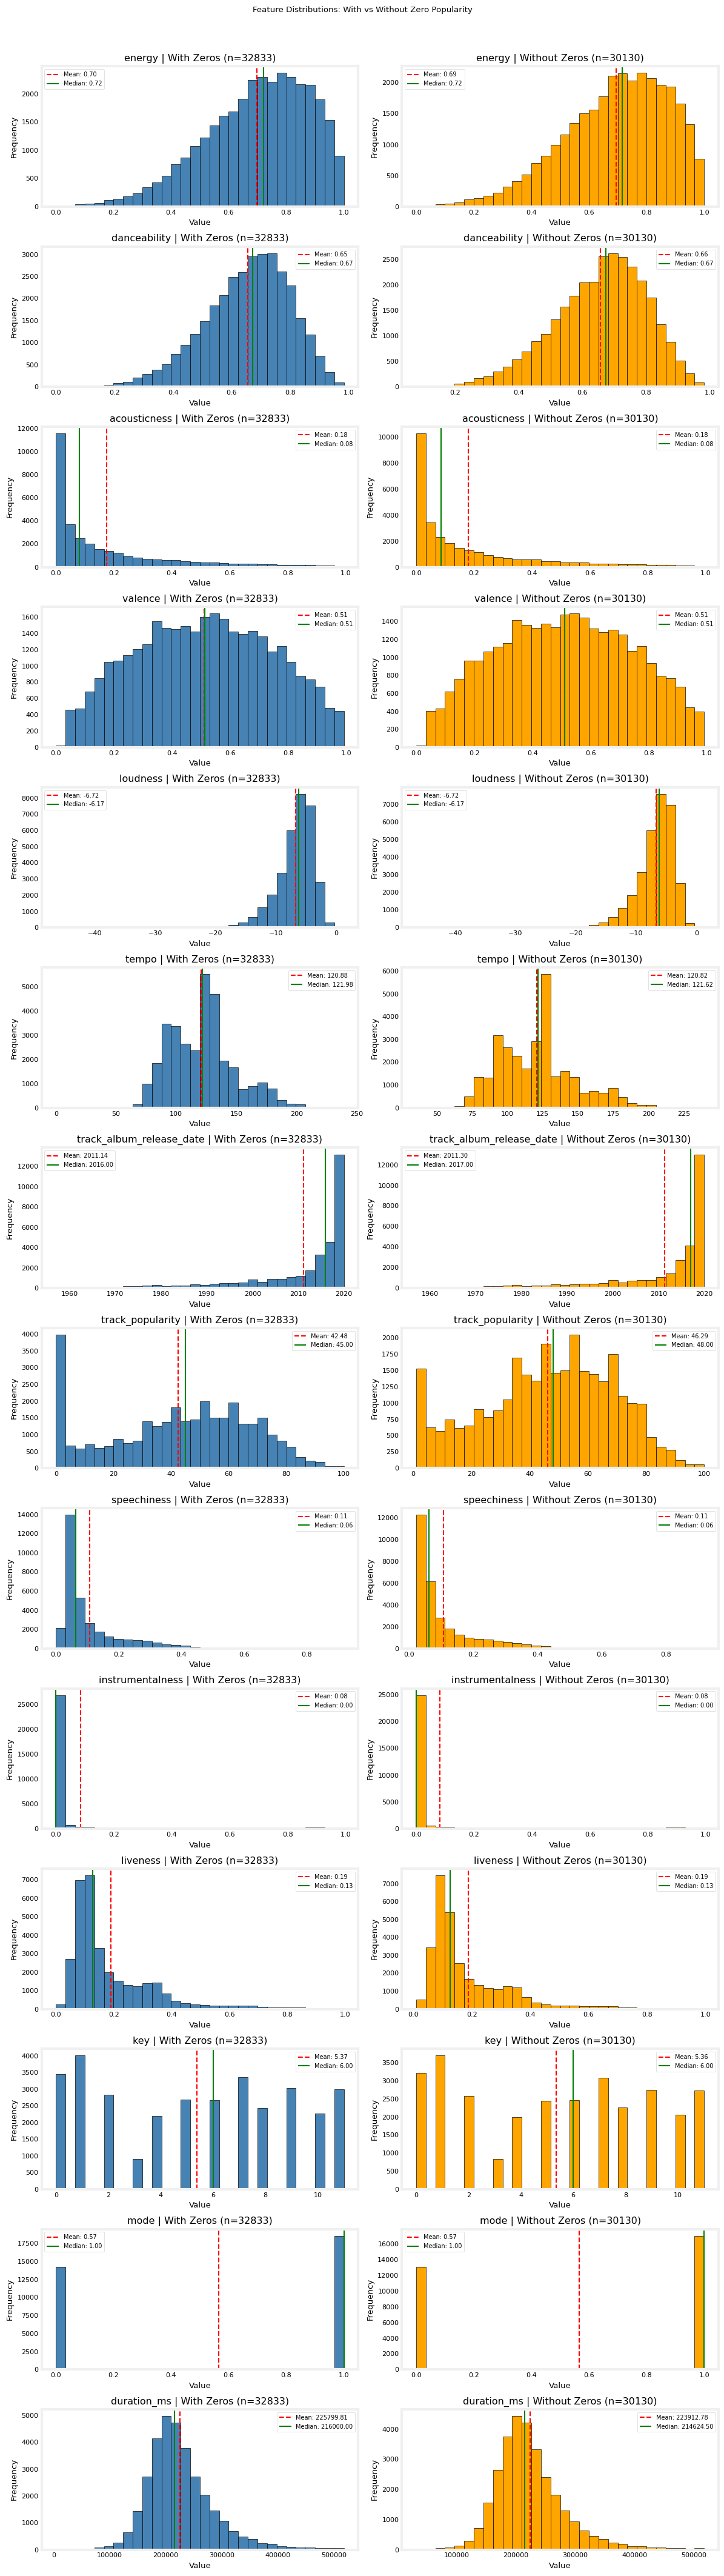

In [ ]:
# Compare all feature distributions with and without zero popularity
df_with_zeros = pd.read_csv("spotify_songs.csv")
year_series = pd.to_datetime(
    df_with_zeros["track_album_release_date"], format="mixed"
).dt.year
df_with_zeros["track_album_release_date"] = year_series.fillna(
    year_series.mean() 
).astype(int)
df_without_zeros = df_with_zeros[df_with_zeros["track_popularity"] != 0]

features = [
    "energy",
    "danceability",
    "acousticness",
    "valence",
    "loudness",
    "tempo",
    "track_album_release_date",
    "track_popularity",
    "speechiness",
    "instrumentalness",
    "liveness",
    "key",
    "mode",
    "duration_ms",
]

fig, axes = plt.subplots(len(features), 2, figsize=(12, len(features) * 3))
plt.suptitle("Feature Distributions: With vs Without Zero Popularity", y=1.01)

for i, feature in enumerate(features):
    for j, (df, label, color) in enumerate(
        [
            (df_with_zeros, f"With Zeros (n={len(df_with_zeros)})", "steelblue"),
            (df_without_zeros, f"Without Zeros (n={len(df_without_zeros)})", "orange"),
        ]
    ):
        ax = axes[i, j]
        mean = df[feature].mean()
        median = df[feature].median()

        ax.hist(df[feature], bins=30, edgecolor="black", color=color)
        ax.axvline(
            mean, color="red", linestyle="--", linewidth=1.5, label=f"Mean: {mean:.2f}"
        )
        ax.axvline(
            median,
            color="green",
            linestyle="-",
            linewidth=1.5,
            label=f"Median: {median:.2f}",
        )
        ax.set_title(f"{feature} | {label}")
        ax.set_xlabel("Value")
        ax.set_ylabel("Frequency")
        ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

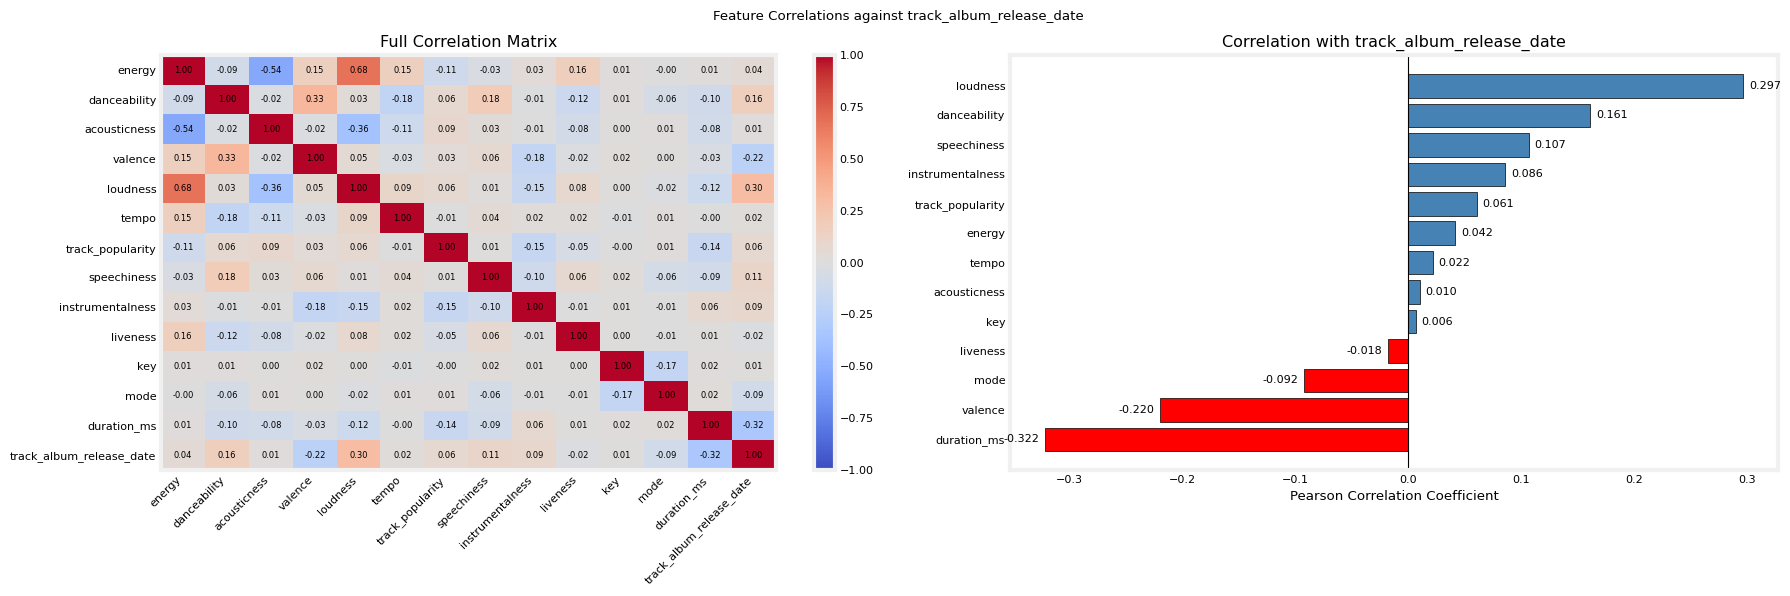

In [ ]:
# Correlation heatmap + correlation bar chart
features_corr = [
    "energy",
    "danceability",
    "acousticness",
    "valence",
    "loudness",
    "tempo",
    "track_popularity",
    "speechiness",
    "instrumentalness",
    "liveness",
    "key",
    "mode",
    "duration_ms",
    "track_album_release_date",
]

corr_matrix = data_frame[features_corr].corr()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
plt.suptitle(f"Feature Correlations against {target}")

# Heatmap using matplotlib imshow
im = axes[0].imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1, aspect="auto")
axes[0].set_xticks(range(len(features_corr)))
axes[0].set_yticks(range(len(features_corr)))
axes[0].set_xticklabels(features_corr, rotation=45, ha="right", fontsize=8)
axes[0].set_yticklabels(features_corr, fontsize=8)
for i in range(len(features_corr)):
    for j in range(len(features_corr)):
        axes[0].text(
            j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha="center", va="center", fontsize=6
        )
plt.colorbar(im, ax=axes[0])
axes[0].set_title("Full Correlation Matrix")

# Bar chart of correlations with target only
target_corr = corr_matrix[target].drop(target).sort_values()
colors = ["red" if v < 0 else "steelblue" for v in target_corr]
axes[1].barh(target_corr.index, target_corr.values, color=colors, edgecolor="black")
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title(f"Correlation with {target}")
axes[1].set_xlabel("Pearson Correlation Coefficient") # inaccurate for non linear data and that data is not wrangled
for i, v in enumerate(target_corr.values):
    axes[1].text(
        v + (0.005 if v >= 0 else -0.005),
        i,
        f"{v:.3f}",
        va="center",
        ha="left" if v >= 0 else "right",
        fontsize=8,
    )

plt.tight_layout()
plt.show()

consider non linear models due to low correlation confirmed with earlier scatter and density

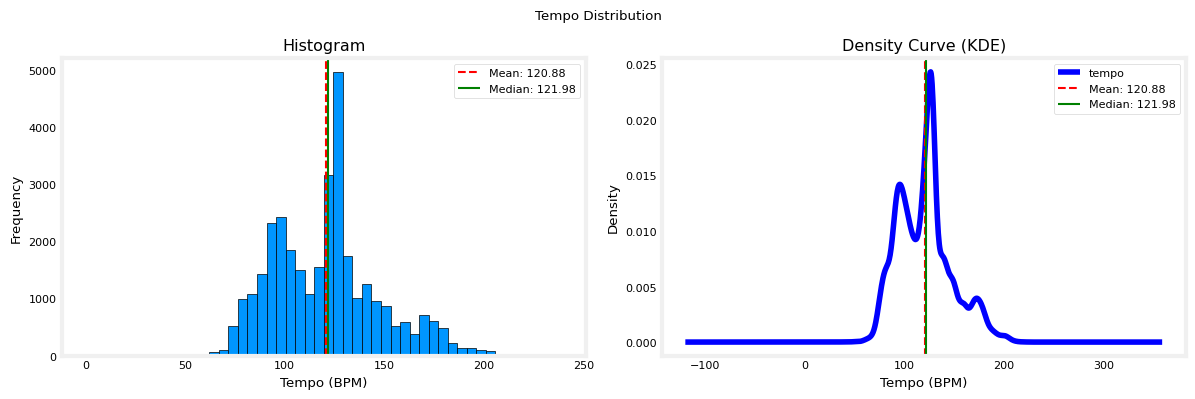

In [10]:
# Detailed tempo distribution plot
mean_tempo = data_frame["tempo"].mean()
median_tempo = data_frame["tempo"].median()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plt.suptitle("Tempo Distribution")

# Histogram
axes[0].hist(data_frame["tempo"], bins=50, edgecolor="black")
axes[0].axvline(
    mean_tempo,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label=f"Mean: {mean_tempo:.2f}",
)
axes[0].axvline(
    median_tempo,
    color="green",
    linestyle="-",
    linewidth=1.5,
    label=f"Median: {median_tempo:.2f}",
)
axes[0].set_title("Histogram")
axes[0].set_xlabel("Tempo (BPM)")
axes[0].set_ylabel("Frequency")
axes[0].legend()

# KDE (smooth curve) to better see the shape
data_frame["tempo"].plot.kde(ax=axes[1], color="blue")
axes[1].axvline(
    mean_tempo,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label=f"Mean: {mean_tempo:.2f}",
)
axes[1].axvline(
    median_tempo,
    color="green",
    linestyle="-",
    linewidth=1.5,
    label=f"Median: {median_tempo:.2f}",
)
axes[1].set_title("Density Curve (KDE)")
axes[1].set_xlabel("Tempo (BPM)")
axes[1].set_ylabel("Density")
axes[1].legend()

plt.tight_layout()
plt.savefig("tempo_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

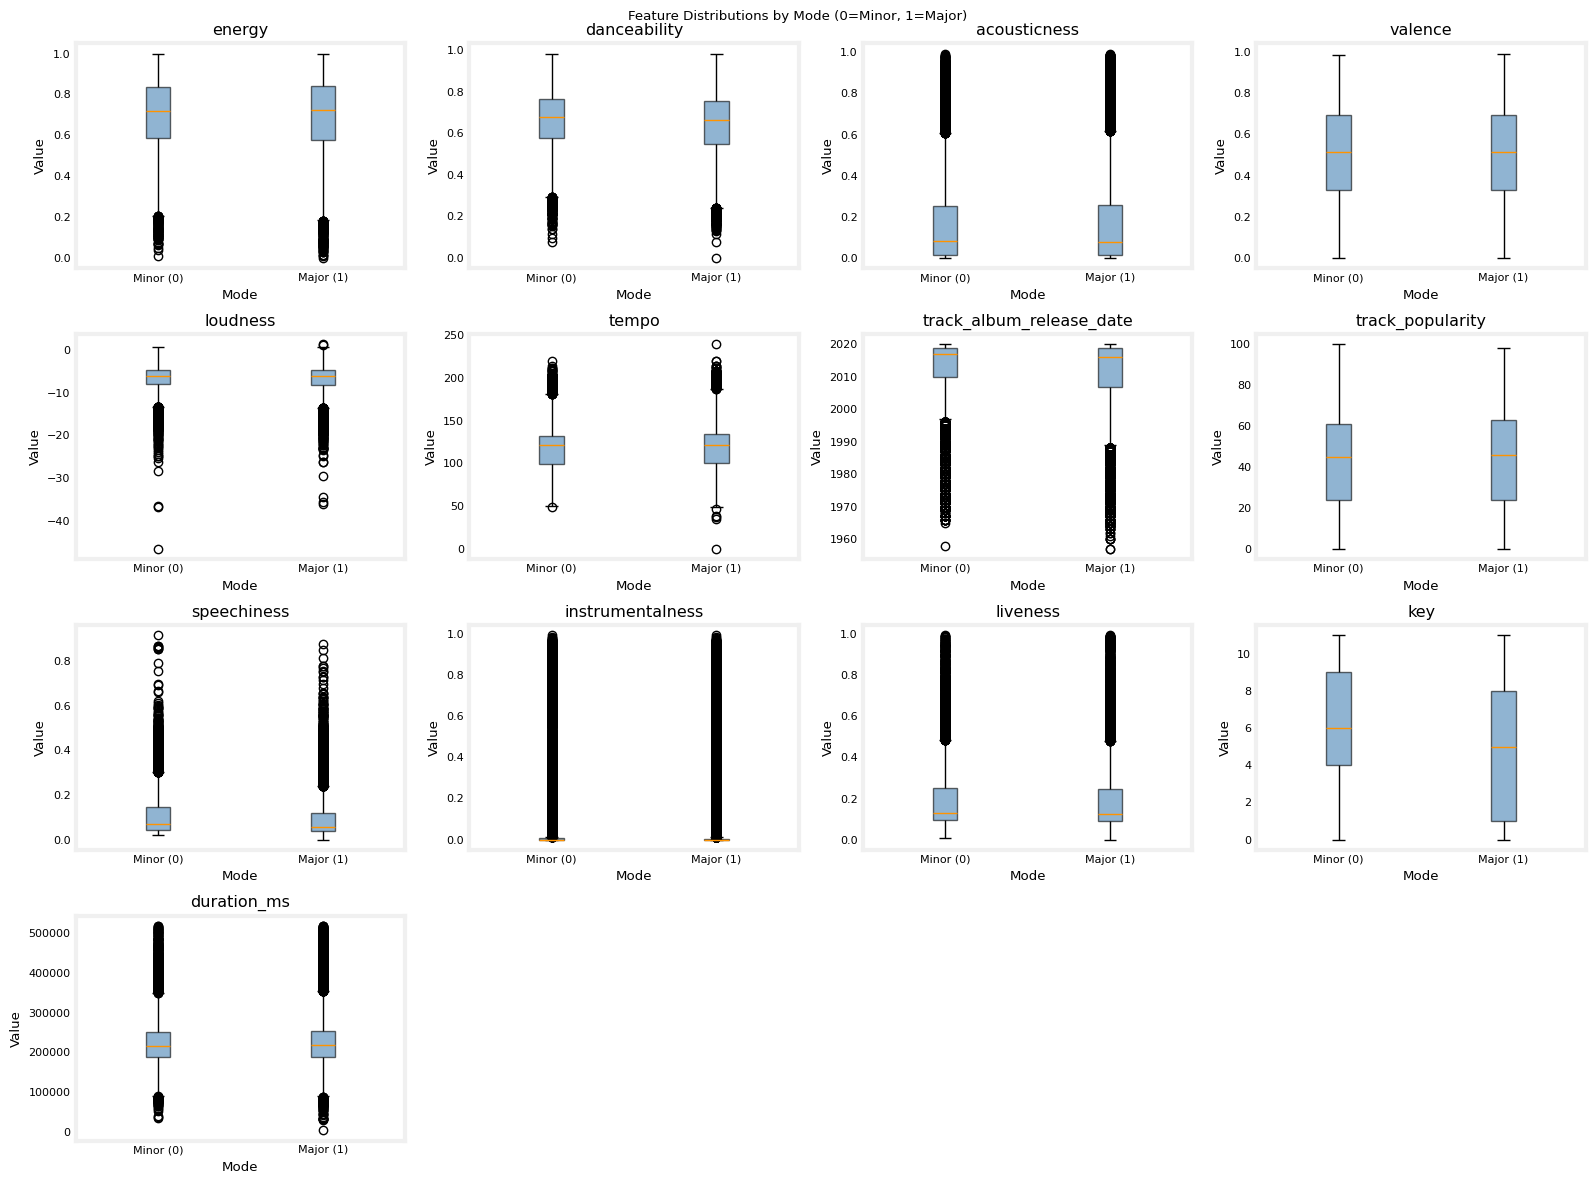

In [25]:
# Graph mode (binary: 0=minor, 1=major) against all features using box plots
features_vs_mode = [
    "energy",
    "danceability",
    "acousticness",
    "valence",
    "loudness",
    "tempo",
    "track_album_release_date",
    "track_popularity",
    "speechiness",
    "instrumentalness",
    "liveness",
    "key",
    "duration_ms",
]

fig, axes = plt.subplots(4, 4, figsize=(16, 12))
plt.suptitle("Feature Distributions by Mode (0=Minor, 1=Major)")

for ax, feature in zip(axes.flatten(), features_vs_mode):
    minor = data_frame[data_frame["mode"] == 0][feature]
    major = data_frame[data_frame["mode"] == 1][feature]

    ax.boxplot(
        [minor, major],
        tick_labels=["Minor (0)", "Major (1)"],
        patch_artist=True,
        boxprops=dict(facecolor="steelblue", alpha=0.6),
    )
    ax.set_title(feature)
    ax.set_xlabel("Mode")
    ax.set_ylabel("Value")

for ax in axes.flatten()[len(features_vs_mode) :]:
    ax.set_visible(False)

plt.tight_layout()
plt.savefig("mode_vs_features.png", dpi=150, bbox_inches="tight")
plt.show()

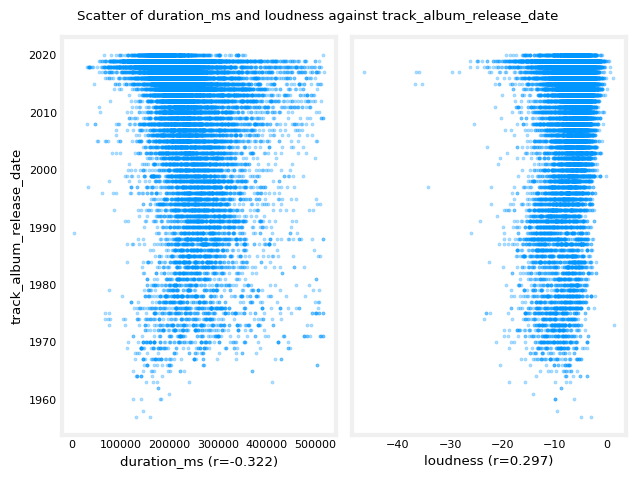

In [27]:
# Scatter plot 2 columns to see the relationship

# x_features = ["energy", "danceability", "acousticness", "valence", "loudness", "tempo", "track_album_release_date"]

# featurex = "energy"
# plt.scatter(data_frame[featurex], data_frame[target])
# plt.title(f"Scatter of {data_frame[featurex].name} against {data_frame[target].name}")
# plt.ylabel(f"{data_frame[target].name} Data")
# plt.xlabel(f"{data_frame[featurex].name} Data")
# plt.show()

# Scatter plot of the 2 strongest correlated features against target (shared y-axis)
fig, (ax1, ax2) = plt.subplots(1, 2, sharey=True)
plt.suptitle(f"Scatter of duration_ms and loudness against {target}")
ax1.set_ylabel(target)

ax1.scatter(data_frame["duration_ms"], data_frame[target], alpha=0.3, s=5)
ax1.set_xlabel("duration_ms (r=-0.322)")

ax2.scatter(data_frame["loudness"], data_frame[target], alpha=0.3, s=5)
ax2.set_xlabel("loudness (r=0.297)")

plt.tight_layout()
plt.show()

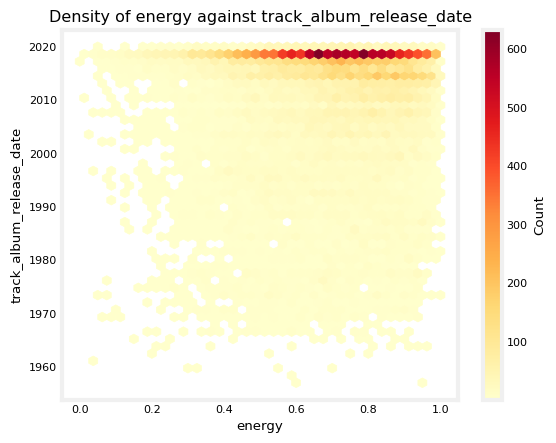

In [ ]:
# check density of hexbin
feature = "energy"

plt.hexbin(
    data_frame[feature], data_frame[target], gridsize=40, cmap="YlOrRd", mincnt=1
)
plt.title(f"Density of {feature} against {target}")
plt.xlabel(feature)
plt.ylabel(target)
plt.colorbar(label="Count")
plt.show()

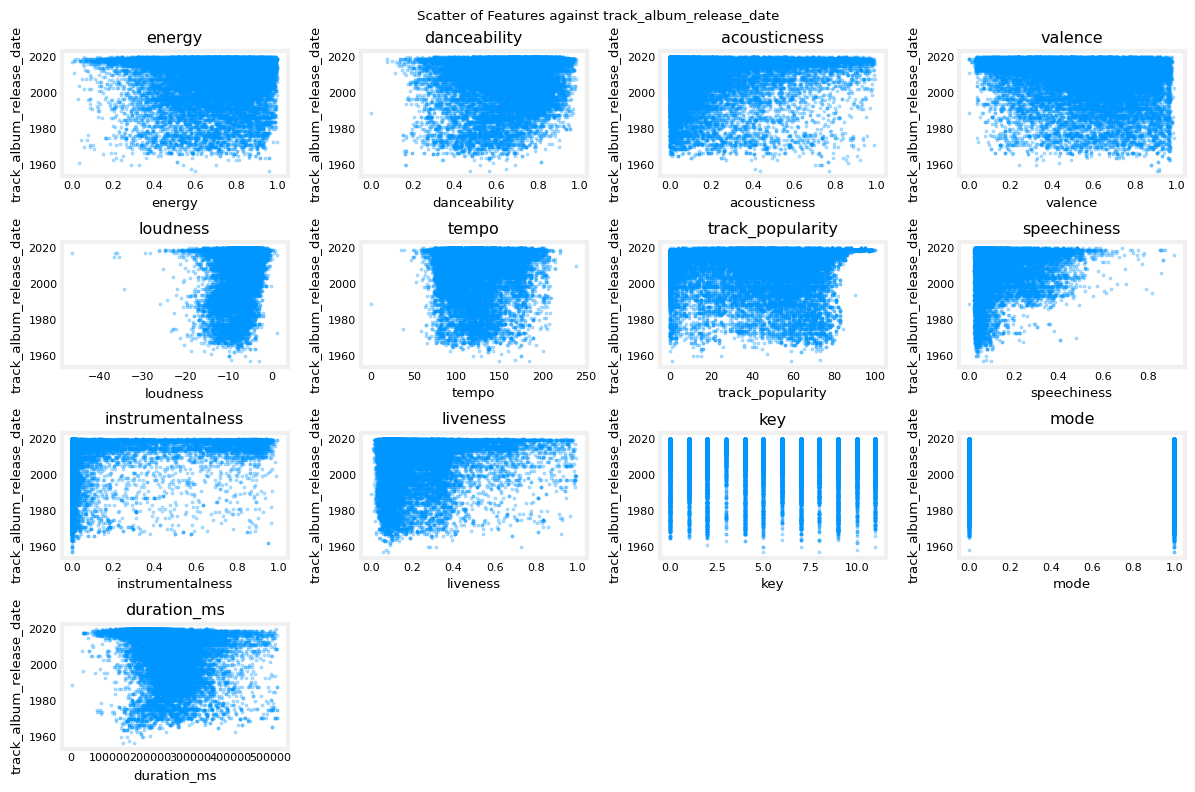

In [20]:


# Scatter plot multiple features against target in one image
x_features = [
    "energy",
    "danceability",
    "acousticness",
    "valence",
    "loudness",
    "tempo",
    "track_popularity",
    "speechiness",
    "instrumentalness",
    "liveness",
    "key",
    "mode",
    "duration_ms"
]

fig, axes = plt.subplots(4, 4, figsize=(12, 8))
plt.suptitle(f"Scatter of Features against {target}")

for ax, feature in zip(axes.flatten(), x_features):
    ax.scatter(data_frame[feature], data_frame[target], alpha=0.3, s=5)
    ax.set_title(feature)
    ax.set_xlabel(feature)
    ax.set_ylabel(target)

# Hide any unused subplots
for ax in axes.flatten()[len(x_features) :]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

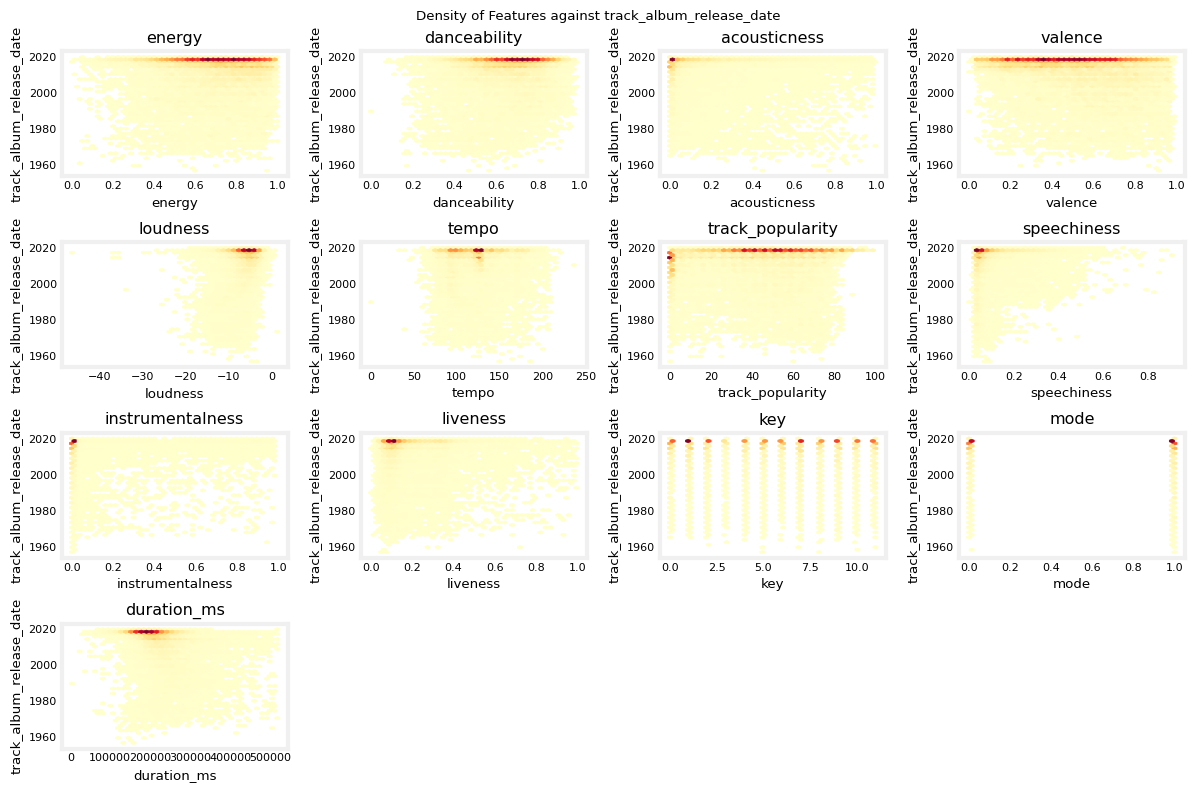

In [23]:
x_features = [
    "energy",
    "danceability",
    "acousticness",
    "valence",
    "loudness",
    "tempo",
    "track_popularity",
    "speechiness",
    "instrumentalness",
    "liveness",
    "key",
    "mode",
    "duration_ms",
]

fig, axes = plt.subplots(4,4, figsize=(12, 8))
plt.suptitle(f"Density of Features against {target}")

for ax, feature in zip(axes.flatten(), x_features):
    ax.hexbin(
        data_frame[feature], data_frame[target], gridsize=40, cmap="YlOrRd", mincnt=1
    )
    ax.set_title(feature)
    ax.set_xlabel(feature)
    ax.set_ylabel(target)

# Hide any unused subplots
for ax in axes.flatten()[len(x_features) :]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

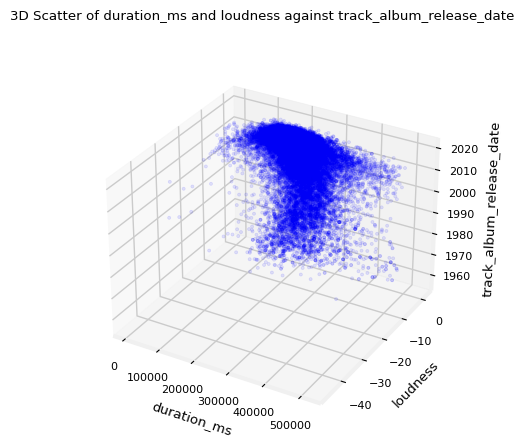

In [29]:
# 3D Scatter plot of the 2 strongest correlated features against target
x_plot = ["duration_ms", "loudness"]

fig = plt.figure()
plt.suptitle(f"3D Scatter of {x_plot[0]} and {x_plot[1]} against {target}")
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    data_frame[x_plot[0]],
    data_frame[x_plot[1]],
    data_frame[target],
    color="blue",
    alpha=0.1,
    s=5,
)

ax.set_xlabel(x_plot[0])
ax.set_ylabel(x_plot[1])
ax.set_zlabel(target)

plt.show()